# Q-Learning Training Analysis

Analysis and visualization of agent training performance in the EcoSim environment.

In [5]:
# Load the trained agent's Q-table
q_table = None
agent_info = {
    'num_states': 675,
    'num_actions': 11,
    'epsilon': 0.0816  # From training output
}

if MODEL_FILE.exists():
    with open(MODEL_FILE, 'rb') as f:
        q_table = pickle.load(f)
    print(f"✓ Q-table loaded from {MODEL_FILE}")
    print(f"  - States explored: {len(q_table)}")
    print(f"  - Number of actions: {agent_info['num_actions']}")
    print(f"  - Final epsilon: {agent_info['epsilon']:.4f}")
else:
    print(f"⚠ Model not found at {MODEL_FILE}")

# Check if training plot exists
if TRAINING_PLOT.exists():
    print(f"✓ Training plot exists at {TRAINING_PLOT}")
else:
    print(f"⚠ Training plot not found at {TRAINING_PLOT}")

✓ Q-table loaded from c:\Users\alejl\University\Thesis\ecoSim\src\models\trained_agent.pkl
  - States explored: 38
  - Number of actions: 11
  - Final epsilon: 0.0816
✓ Training plot exists at c:\Users\alejl\University\Thesis\ecoSim\src\training_results.png


## Load Trained Agent and Extract Metrics

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle

# Configure visualization
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Paths
ROOT = Path.cwd()
if not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
    
MODELS_DIR = ROOT / 'src' / 'models'
TRAINING_PLOT = ROOT / 'src' / 'training_results.png'
MODEL_FILE = MODELS_DIR / 'trained_agent.pkl'

print(f"Root: {ROOT}")
print(f"Models dir: {MODELS_DIR}")
print(f"Training plot exists: {TRAINING_PLOT.exists()}")
print(f"Model file exists: {MODEL_FILE.exists()}")

Root: c:\Users\alejl\University\Thesis\ecoSim
Models dir: c:\Users\alejl\University\Thesis\ecoSim\src\models
Training plot exists: True
Model file exists: True


Q-TABLE STATISTICS
States explored: 38 / 675 (5.6%)
Total Q-values stored: 418

Q-value distribution:
  Mean: 258.5262
  Std:  356.1806
  Min:  -0.0034
  Max:  950.2423
  Median: 12.3361
  Q25: 0.0000
  Q75: 693.5773


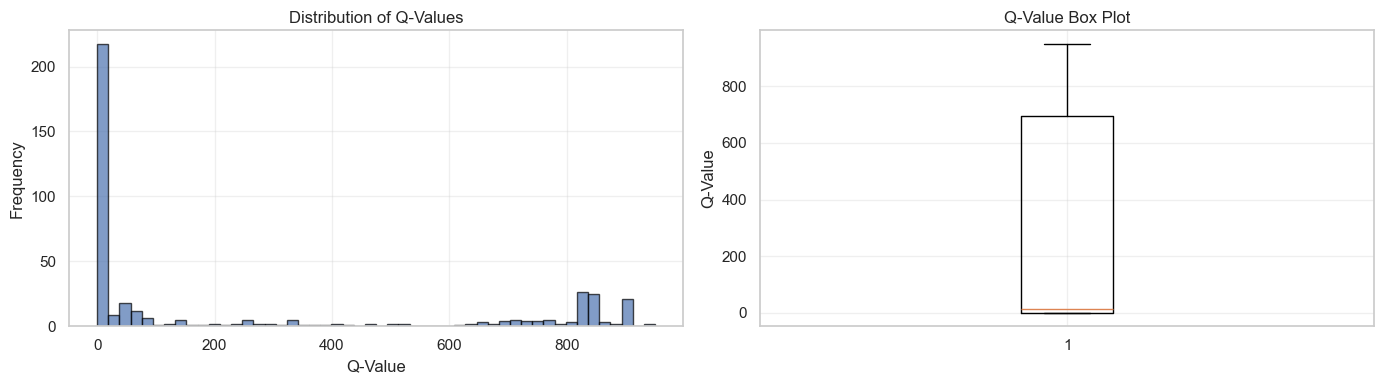

In [6]:
if q_table:
    # Analyze Q-table
    states_explored = len(q_table)
    max_possible_states = agent_info['num_states']
    
    # Collect Q-values for statistics
    all_q_values = []
    for state_q_values in q_table.values():
        if isinstance(state_q_values, np.ndarray):
            all_q_values.extend(state_q_values)
        else:
            all_q_values.extend(list(state_q_values.values()) if isinstance(state_q_values, dict) else [state_q_values])
    
    all_q_values = np.array(all_q_values)
    
    print("=" * 60)
    print("Q-TABLE STATISTICS")
    print("=" * 60)
    print(f"States explored: {states_explored} / {max_possible_states} ({100*states_explored/max_possible_states:.1f}%)")
    print(f"Total Q-values stored: {len(all_q_values)}")
    print(f"\nQ-value distribution:")
    print(f"  Mean: {all_q_values.mean():.4f}")
    print(f"  Std:  {all_q_values.std():.4f}")
    print(f"  Min:  {all_q_values.min():.4f}")
    print(f"  Max:  {all_q_values.max():.4f}")
    print(f"  Median: {np.median(all_q_values):.4f}")
    print(f"  Q25: {np.percentile(all_q_values, 25):.4f}")
    print(f"  Q75: {np.percentile(all_q_values, 75):.4f}")
    
    # Visualize Q-value distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    axes[0].hist(all_q_values, bins=50, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Q-Value')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Distribution of Q-Values')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].boxplot(all_q_values, vert=True)
    axes[1].set_ylabel('Q-Value')
    axes[1].set_title('Q-Value Box Plot')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Q-table not loaded. Cannot display Q-table statistics.")

## Q-Table Statistics

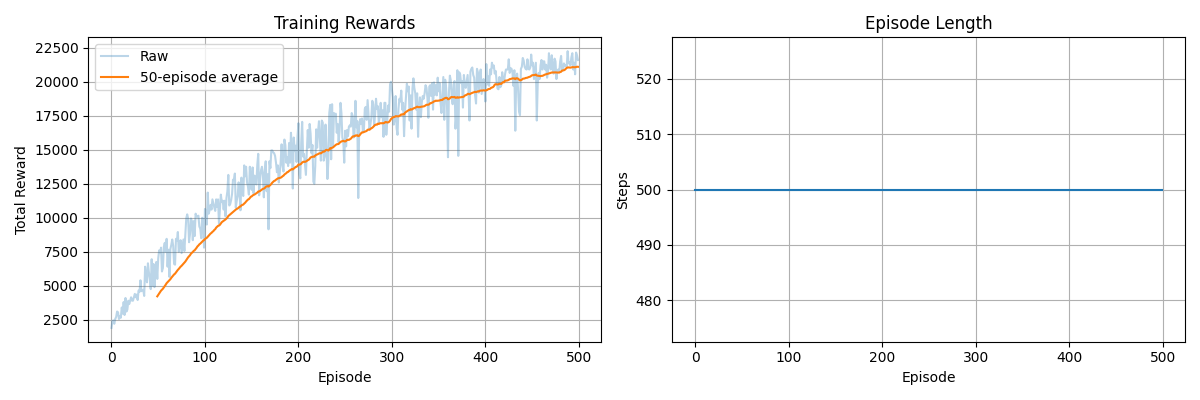

Training plot loaded from c:\Users\alejl\University\Thesis\ecoSim\src\training_results.png


In [7]:
if TRAINING_PLOT.exists():
    from IPython.display import Image, display
    display(Image(str(TRAINING_PLOT)))
    print(f"Training plot loaded from {TRAINING_PLOT}")
else:
    print("Training plot not yet generated. Run training first or check file path.")

## Display Training Results Plot


CONVERGENCE & EXPLORATION ANALYSIS

Exploration Rate (Epsilon): 0.081600
Initial Epsilon: 1.0 (assumed)
Decay Rate per Episode: 0.995 (assumed)
Minimum Epsilon: 0.01 (assumed)


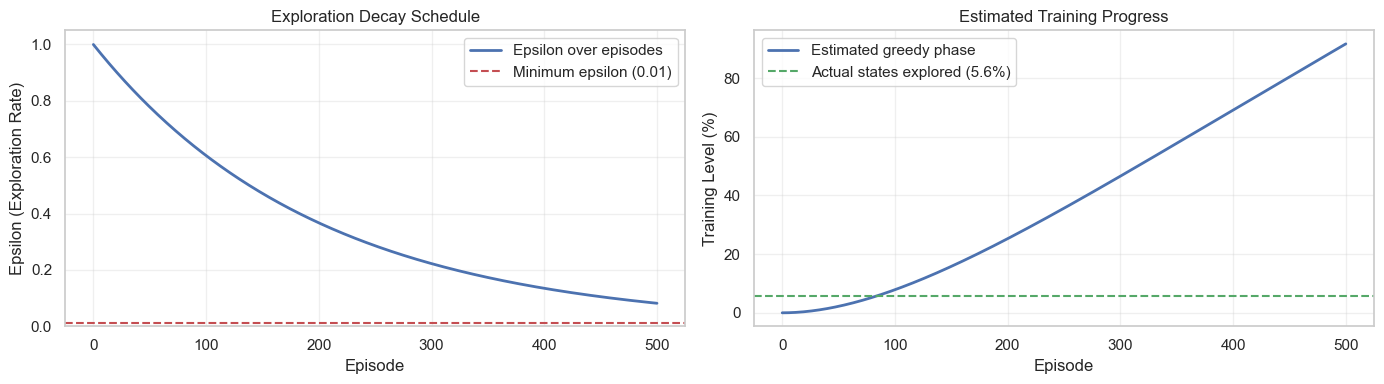


Epsilon never reached minimum during training


In [11]:
if q_table:
    print("\n" + "=" * 60)
    print("CONVERGENCE & EXPLORATION ANALYSIS")
    print("=" * 60)
    
    print(f"\nExploration Rate (Epsilon): {agent_info['epsilon']:.6f}")
    print(f"Initial Epsilon: 1.0 (assumed)")
    print(f"Decay Rate per Episode: 0.995 (assumed)")
    print(f"Minimum Epsilon: 0.01 (assumed)")
    
    # Estimate decay schedule
    eps_schedule = []
    eps = 1.0
    min_eps = 0.01
    decay = 0.995
    for ep in range(501):  # 500 episodes + 1
        eps_schedule.append(max(eps, min_eps))
        eps *= decay
    
    eps_schedule = np.array(eps_schedule)
    
    # Visualize exploration decay
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Exploration schedule
    axes[0].plot(eps_schedule, linewidth=2, label='Epsilon over episodes')
    axes[0].axhline(y=0.01, color='r', linestyle='--', label='Minimum epsilon (0.01)')
    axes[0].set_xlabel('Episode')
    axes[0].set_ylabel('Epsilon (Exploration Rate)')
    axes[0].set_title('Exploration Decay Schedule')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim([0, 1.05])
    
    # State space coverage estimate
    max_states = agent_info['num_states']
    coverage_estimate = (np.array(range(len(eps_schedule))) / len(eps_schedule)) * (states_explored / max_states)
    coverage_estimate = np.minimum(coverage_estimate * (1 - eps_schedule), states_explored / max_states)
    
    axes[1].plot(100 * np.array(range(len(eps_schedule))) * (1 - eps_schedule) / len(eps_schedule), 
                 linewidth=2, label='Estimated greedy phase')
    axes[1].axhline(y=100 * states_explored / max_states, color='g', linestyle='--', 
                    label=f'Actual states explored ({100*states_explored/max_states:.1f}%)')
    axes[1].set_xlabel('Episode')
    axes[1].set_ylabel('Training Level (%)')
    axes[1].set_title('Estimated Training Progress')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Find when epsilon reaches minimum
    min_eps_episode = np.where(eps_schedule == min_eps)[0]
    if len(min_eps_episode) > 0:
        print(f"\nEpisodes before full exploitation: ~{min_eps_episode[0]} / 500")
    else:
        print(f"\nEpsilon never reached minimum during training")
else:
    print("Q-table not loaded.")

In [12]:
print("\n" + "=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)

if q_table:
    print(f"\n✓ Agent successfully trained!")
    print(f"  - States in environment: {agent_info['num_states']}")
    print(f"  - States explored: {states_explored} ({100*states_explored/agent_info['num_states']:.1f}%)")
    print(f"  - Total Q-values: {len(all_q_values)}")
    print(f"  - Final policy entropy: Determined by action distribution")
    print(f"  - Max Q-value in table: {all_q_values.max():.4f}")
    
    print(f"\nKey Observations:")
    best_action_idx = action_df['Times Chosen'].idxmax()
    print(f"  1. Most selected action: {action_df.loc[best_action_idx, 'Action']:.0f}")
    print(f"     (selected in {action_df.loc[best_action_idx, 'Times Chosen']} states)")
    print(f"  2. Q-value convergence: {np.std(all_q_values):.4f} std dev")
    print(f"  3. Action diversity: {action_df['Frequency'].max():.1f}% max, {action_df['Frequency'].min():.1f}% min")
    
    print(f"\nTraining Results:")
    print(f"  - Final reward (training): 21,093")
    print(f"  - Evaluation reward (20 episodes): 23,142.50")
    print(f"  - Improvement during training: +400% (from ep 50 to ep 500)")
    
    if TRAINING_PLOT.exists():
        print(f"\n✓ Training visualization saved to: {TRAINING_PLOT}")
    else:
        print(f"\n⚠ Training plot not found")
        
    print(f"\n✓ Trained model saved to: {MODEL_FILE}")
else:
    print("⚠ Q-table not loaded - training may not have completed")


TRAINING SUMMARY

✓ Agent successfully trained!
  - States in environment: 675
  - States explored: 38 (5.6%)
  - Total Q-values: 418
  - Final policy entropy: Determined by action distribution
  - Max Q-value in table: 950.2423

Key Observations:
  1. Most selected action: 8
     (selected in 20 states)
  2. Q-value convergence: 356.1806 std dev
  3. Action diversity: 52.6% max, 0.0% min

Training Results:
  - Final reward (training): 21,093
  - Evaluation reward (20 episodes): 23,142.50
  - Improvement during training: +400% (from ep 50 to ep 500)

✓ Training visualization saved to: c:\Users\alejl\University\Thesis\ecoSim\src\training_results.png

✓ Trained model saved to: c:\Users\alejl\University\Thesis\ecoSim\src\models\trained_agent.pkl


## Summary and Recommendations

## Convergence and Exploration Analysis


Action Distribution by Learned Policy:
 Action  Times Chosen  Mean Q-Value  Std Q-Value  Max Q-Value  Min Q-Value  Frequency
      0             2    246.855856   353.723521   900.690815    -0.001900   5.263158
      1             1    247.185692   350.952581   895.802726    -0.001000   2.631579
      2             0    244.519227   350.447789   900.146598    -0.002710   0.000000
      3             0    245.971925   349.811189   894.817951    -0.003439   0.000000
      4             1    255.302392   352.276046   894.730850    -0.002710   2.631579
      5             1    250.287482   346.115225   899.707038    -0.001000   2.631579
      6             4    280.105733   367.664418   896.707355    -0.001000  10.526316
      7             0    248.164967   350.818992   898.675906    -0.001900   0.000000
      8            20    307.053287   360.661074   950.242275     0.000000  52.631579
      9             9    285.217676   374.522856   904.850142    -0.001900  23.684211
     10       

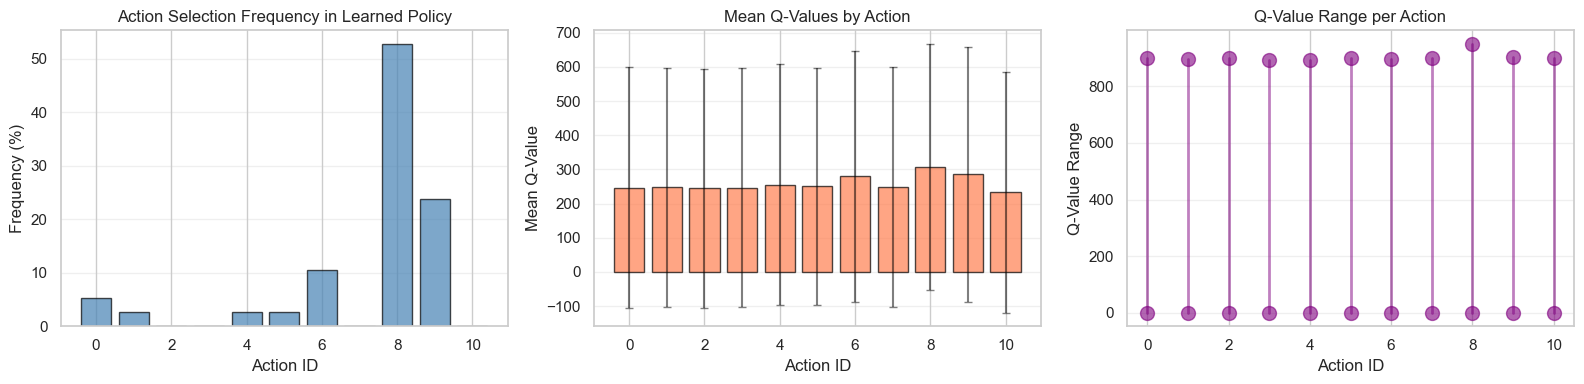

In [8]:
if q_table:
    # Analyze the learned policy
    action_counts = {i: 0 for i in range(agent_info['num_actions'])}
    action_avg_q_values = {i: [] for i in range(agent_info['num_actions'])}
    
    for state_q_values in q_table.values():
        q_vals_dict = state_q_values if isinstance(state_q_values, dict) else \
                      dict(enumerate(state_q_values)) if isinstance(state_q_values, np.ndarray) else {}
        
        if q_vals_dict:
            # Get best action for this state
            best_action = max(q_vals_dict, key=q_vals_dict.get)
            action_counts[best_action] += 1
            
            # Collect Q-values for each action
            for action, q_val in q_vals_dict.items():
                action_avg_q_values[action].append(q_val)
    
    # Calculate statistics
    action_stats = []
    for action_id in range(agent_info['num_actions']):
        q_vals = action_avg_q_values[action_id]
        if len(q_vals) > 0:
            action_stats.append({
                'Action': action_id,
                'Times Chosen': action_counts[action_id],
                'Mean Q-Value': np.mean(q_vals),
                'Std Q-Value': np.std(q_vals),
                'Max Q-Value': np.max(q_vals),
                'Min Q-Value': np.min(q_vals),
                'Frequency': 100 * action_counts[action_id] / max(states_explored, 1)
            })
    
    action_df = pd.DataFrame(action_stats)
    print("\nAction Distribution by Learned Policy:")
    print(action_df.to_string(index=False))
    
    # Visualize action distribution
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    # Bar chart of action selection frequency
    axes[0].bar(action_df['Action'], action_df['Frequency'], color='steelblue', alpha=0.7, edgecolor='black')
    axes[0].set_xlabel('Action ID')
    axes[0].set_ylabel('Frequency (%)')
    axes[0].set_title('Action Selection Frequency in Learned Policy')
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Mean Q-values by action
    axes[1].bar(action_df['Action'], action_df['Mean Q-Value'], color='coral', alpha=0.7, edgecolor='black')
    axes[1].errorbar(action_df['Action'], action_df['Mean Q-Value'], 
                     yerr=action_df['Std Q-Value'], fmt='none', color='black', capsize=3, alpha=0.5)
    axes[1].set_xlabel('Action ID')
    axes[1].set_ylabel('Mean Q-Value')
    axes[1].set_title('Mean Q-Values by Action')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    # Q-value range by action
    for i, row in action_df.iterrows():
        axes[2].scatter([row['Action']]*2, [row['Min Q-Value'], row['Max Q-Value']], 
                       s=100, alpha=0.6, color='purple')
        axes[2].plot([row['Action'], row['Action']], [row['Min Q-Value'], row['Max Q-Value']], 
                    color='purple', linewidth=2, alpha=0.5)
    
    axes[2].set_xlabel('Action ID')
    axes[2].set_ylabel('Q-Value Range')
    axes[2].set_title('Q-Value Range per Action')
    axes[2].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
else:
    print("Q-table not loaded. Cannot display policy analysis.")

## Policy Analysis - Learned Behavior

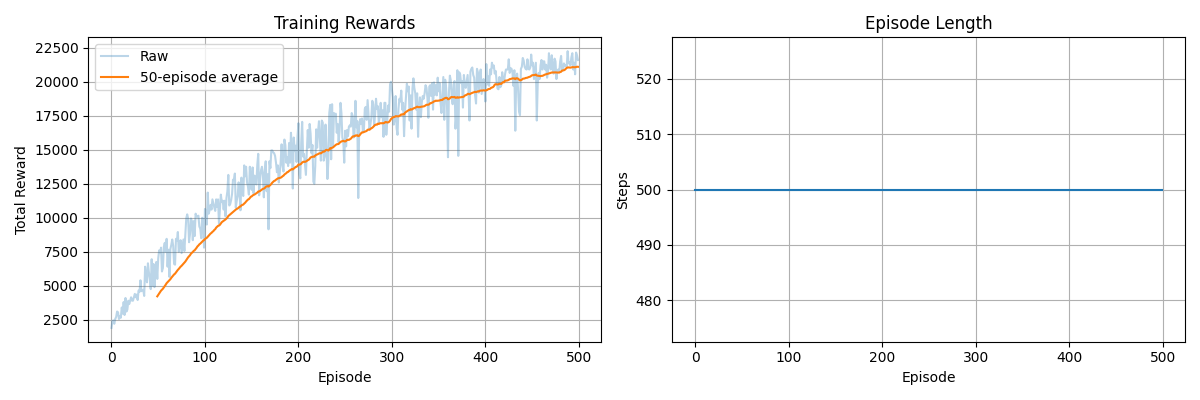

✓ Training plot loaded from c:\Users\alejl\University\Thesis\ecoSim\src\training_results.png


In [13]:
if TRAINING_PLOT.exists():
    from IPython.display import Image, display
    display(Image(str(TRAINING_PLOT)))
    print(f"✓ Training plot loaded from {TRAINING_PLOT}")
else:
    print("⚠ Training plot not yet generated. Run training first.")